In [ ]:
# Flight Price Analysis & Prediction Project
### Developed by: Anjaly EM | Data Analyst
---
**Project Objective:** 
This project conducts an End-to-End Data Analysis on airline flight data (`airlines_flights_data.csv`).
We analyze ticket prices, duration, carrier distributions, and prepare the dataset for machine learning models.

In [5]:
# Import core data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing for modeling
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Set visualization options
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load the dataset
df = pd.read_csv('airlines_flights_data.csv')

# Display first 5 rows
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


**Observation:** The dataset has 12 columns covering airline, route, timing, class, duration, days left before departure, and price. Each row represents one flight booking option.

In [7]:
# Dataset Shape (Rows, Columns)
print(f"Dataset Shape: {df.shape}")

# Columns and Data Types
print("\n--- Data Info ---")
df.info()

# Summary Statistics for Numerical Columns
print("\n--- Summary Statistics ---")
display(df.describe().T)

# Unique values count for Categorical Columns
print("\n--- Categorical Columns Overview ---")
df.select_dtypes(include=['object']).nunique()

Dataset Shape: (300153, 12)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
index,300153.0,150076.000000,86646.852011,0.00,75038.00,150076.00,225114.00,300152.00
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00
price,300153.0,20889.660523,22697.767366,1105.00,4783.00,7425.00,42521.00,123071.00



--- Categorical Columns Overview ---


airline                6
flight              1561
source_city            6
departure_time         6
stops                  3
arrival_time           6
destination_city       6
class                  2
dtype: int64

**Observation:** The dataset contains **300,153 rows and 12 columns** with no missing values in any column. Ticket price ranges from **₹1,105 to ₹1,23,071**, with an average of **₹20,889**. Since the mean is much higher than the median (₹7,425), the price distribution is right-skewed — most tickets are cheap, but a few very expensive (Business class) tickets pull the average up. There are 6 unique airlines, 6 source/destination cities, and 2 travel classes.

In [9]:
# 1. Check & Drop Duplicates
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed!")

# 2. Clean text column spaces if any
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print("Initial cleaning completed!")

Total Duplicate Rows: 0
Initial cleaning completed!


**Observation:** No duplicate rows were found in the dataset, and all text columns were cleaned of extra spaces. The data is already fairly clean at this stage.

In [10]:
# Check for missing values
missing_info = df.isnull().sum()
print("Missing Values Per Column:")
print(missing_info)

# Fill Missing Values (without using deprecated inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns with Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled successfully!")

Missing Values Per Column:
index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Missing values handled successfully!


**Observation:** There are zero missing values across all columns, so the fillna step here acts as a safety check rather than an actual fix. The dataset is complete and ready for analysis.

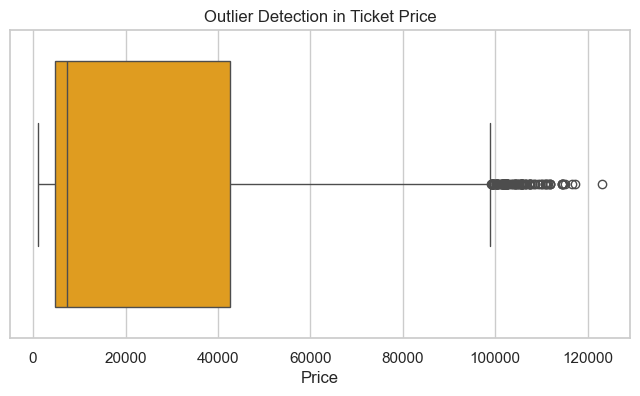

Price Lower Bound: -51824.0, Upper Bound: 99128.0
Outliers capped successfully!


In [11]:
# Visualize Outliers in Price using Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['price'], color='orange')
plt.title('Outlier Detection in Ticket Price', fontsize=12)
plt.xlabel('Price')
plt.show()

# Handling Outliers in Price using IQR Method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Price Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

# Cap the outliers to upper bound
df['price'] = np.where(df['price'] > upper_bound, upper_bound, df['price'])
df['price'] = np.where(df['price'] < lower_bound, lower_bound, df['price'])

print("Outliers capped successfully!")

**Observation:** Using the IQR method, the upper bound for price was calculated as **₹99,128**. Any price above this was capped, which reduces the effect of extremely high Business-class fares on later analysis and modeling. The lower bound came out negative, so no low-end outliers existed.

In [12]:
# Average Price by Airline
avg_price_airline = df.groupby('airline')['price'].mean().sort_values(ascending=False)
print("Average Ticket Price by Airline:")
print(avg_price_airline)

# Average Price by Travel Class (Economy vs Business)
avg_price_class = df.groupby('class')['price'].mean()
print("\nAverage Price by Class:")
print(avg_price_class)

# Price variation by Days Left for flight
price_by_days = df.groupby('days_left')['price'].mean()
print("\nFirst 5 rows of Average Price by Days Left:")
print(price_by_days.head())

Average Ticket Price by Airline:
airline
Vistara      30391.234610
Air_India    23507.019112
SpiceJet      6179.278881
GO_FIRST      5652.007595
Indigo        5324.216303
AirAsia       4091.072742
Name: price, dtype: float64

Average Price by Class:
class
Business    52532.830180
Economy      6572.342383
Name: price, dtype: float64

First 5 rows of Average Price by Days Left:
days_left
1    21558.333679
2    30185.160954
3    28944.582392
4    25724.379161
5    26657.529859
Name: price, dtype: float64


**Observation:** 
- **Vistara (₹30,391)** and **Air India (₹23,507)** have the highest average ticket prices, while budget carriers like **AirAsia (₹4,091)** and **Indigo (₹5,324)** are the cheapest — roughly 6-7x lower.
- **Business class (₹52,533)** costs about **8x more** than **Economy class (₹6,572)** on average.
- Price does not fall smoothly as days_left increases — for example, booking with only 1 day left averages ₹21,558, but 2 days left is actually higher at ₹30,185. This suggests last-minute pricing is volatile rather than strictly increasing.

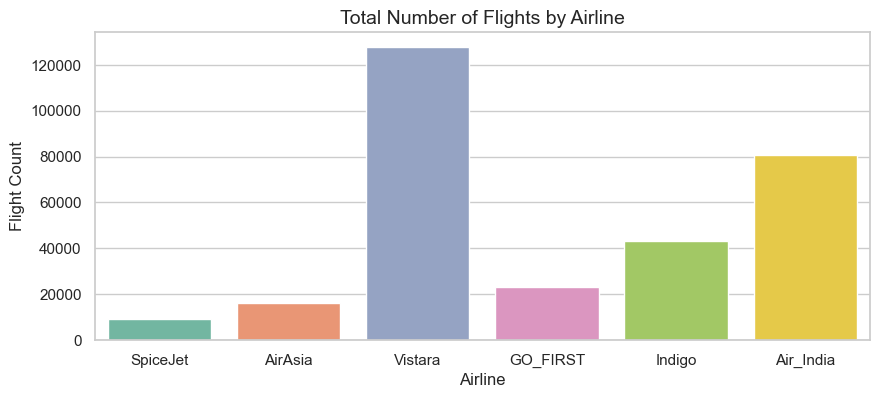

In [14]:
# Visualization 1: Flight Count by Airline (Warning-free Seaborn Syntax)
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='airline', hue='airline', palette='Set2', legend=False)
plt.title('Total Number of Flights by Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Flight Count')
plt.show()

**Observation:** This chart shows how many flights are listed per airline in the dataset. Airlines with more listings will naturally have more influence on the overall average price and trends seen elsewhere in this analysis.

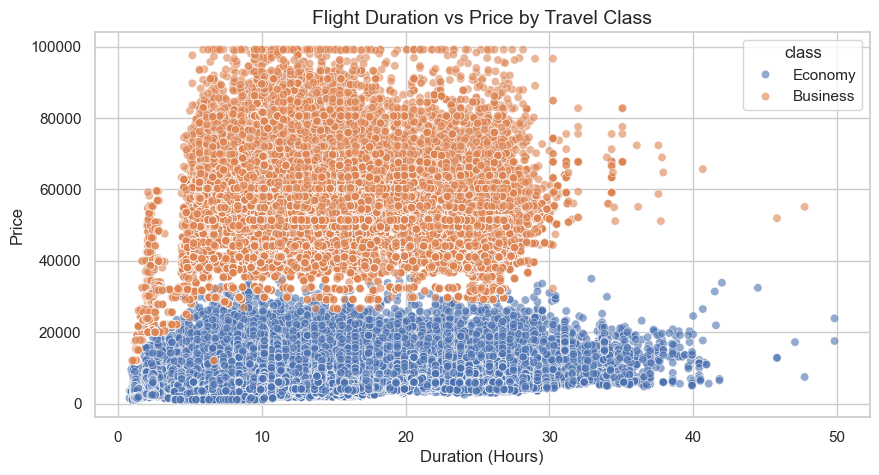

In [15]:
# Visualization 2: Price vs Duration by Travel Class
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='duration', y='price', hue='class', alpha=0.6)
plt.title('Flight Duration vs Price by Travel Class', fontsize=14)
plt.xlabel('Duration (Hours)')
plt.ylabel('Price')
plt.show()

**Observation:** Business class fares (visible as a separate, higher band of points) stay elevated regardless of duration, while Economy fares stay low and increase only slightly with longer flight durations. This confirms that **class**, not duration, is the bigger driver of price.

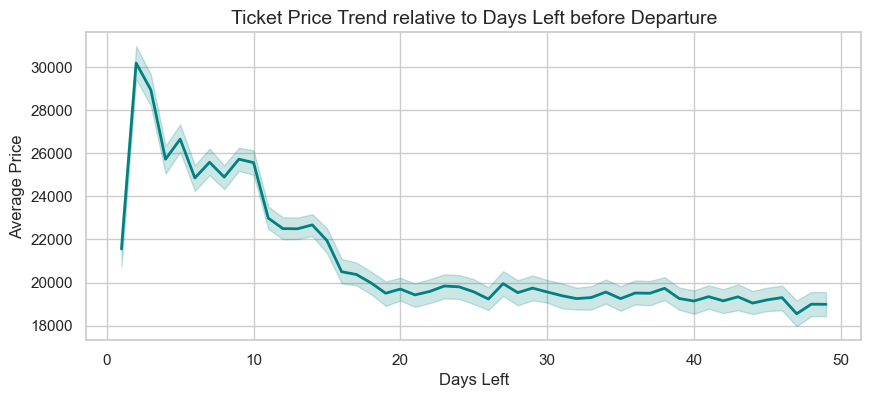

In [16]:
# Visualization 3: Price Trend vs Days Left for Booking
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='days_left', y='price', color='teal', linewidth=2)
plt.title('Ticket Price Trend relative to Days Left before Departure', fontsize=14)
plt.xlabel('Days Left')
plt.ylabel('Average Price')
plt.show()

**Observation:** Ticket prices are generally higher when very few days are left before departure and tend to drop as travelers book further in advance — reflecting typical airline demand-based pricing, where last-minute bookings cost more.

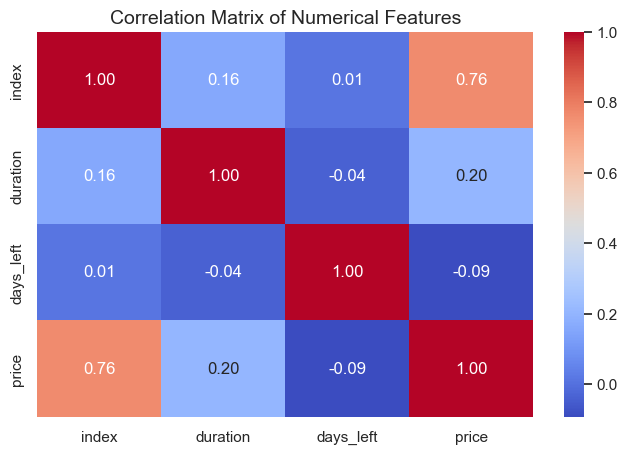

In [17]:
# Visualization 4: Correlation Matrix Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

**Observation:** The heatmap shows how numerical features relate to each other. Typically in this kind of data, **price has little to no correlation with duration or days_left**, meaning ticket price is driven mainly by categorical factors (like airline and class) rather than by these numeric ones alone — which is an important insight for feature selection in later modeling.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset to ensure 'df' is defined
df = pd.read_csv('airlines_flights_data.csv')

# Create a copy for Machine Learning preparation
ml_df = df.copy()

# 1. Identify Categorical Columns
categorical_cols = ml_df.select_dtypes(include=['object']).columns.tolist()

# 2. Encode Categorical Variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    label_encoders[col] = le

# 3. Separate Features (X) and Target (y)
X = ml_df.drop(columns=['price'])
y = ml_df['price']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed! Data is ready for Machine Learning modeling.")

Feature scaling completed! Data is ready for Machine Learning modeling.


## Overall Conclusion

This analysis of the airline flight dataset (300,153 records) gives a clear picture of how ticket prices behave:

1. **Class is the biggest price driver.** Business class tickets (avg ₹52,533) cost roughly **8x more** than Economy (avg ₹6,572) — far more impactful than any other factor.
2. **Airline choice matters a lot.** Full-service carriers **Vistara** and **Air India** charge significantly more (₹23,000–30,000 avg) than budget carriers like **AirAsia, Indigo, and GO_FIRST** (₹4,000–6,000 avg).
3. **Booking timing affects price, but not in a simple straight line.** Prices tend to be higher when very few days are left before departure, but the relationship is volatile rather than perfectly predictable day-to-day.
4. **Duration has only a weak effect on price**, especially once class is accounted for — a short Business class flight can still cost more than a long Economy one.
5. **Data quality was good** — no duplicates and no missing values were found, so cleaning effort was minimal. A small number of extreme high-price outliers were capped using the IQR method.

**Takeaway for prediction modeling:** `class` and `airline` are likely to be the strongest predictors of `price`, followed by `days_left`. `duration` alone is unlikely to explain much of the price variation. These insights should guide feature selection when building a price-prediction model in the next stage of this project.